# PHASE 5: Model Selection, Training & Validation
**Traceability**
- Issue ID: #5 Model Selection, Training & Validation

**External References**:
- [Wassim Derbel - NASA Predictive Maintenance](https://www.kaggle.com/code/wassimderbel/nasa-predictive-maintenance-rul) (XGBoost & CV Strategy)
- [Carl Kirstein - Predictive Maintenance](https://www.kaggle.com/code/carlkirstein/predictive-maintenance-nasa-turbofan-regression) (Classical Baselines)

## 1. Objectives
- **Reasoning**: We need a validation strategy that mimics deployment. Random splitting causes data leakage because samples from the same engine are highly correlated. We use **GroupKFold**.
- **Action**: Tune hyperparameters for the best model.
- **Evaluation**: Analyze residuals to ensure no systematic bias.

## 2. Model Strategy
- Linear Regression
- XGBoost
- Random Forest
- Support Vector Regression (SVR)
- Neural Network (ANN)
- **Evaluation**: Compare model performance using metrics like RMSE, MAE, and R².

##  Common Blocks 
Common Imports

In [15]:
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from pathlib import Path
import pickle

from sklearn.model_selection import GroupKFold, cross_validate
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import MinMaxScaler

from sklearn.metrics import root_mean_squared_error, mean_absolute_error, r2_score
from sklearn.model_selection import KFold

Load Data + Common Setup

In [16]:
# 1. Setup constants
# Files are in the current working directory
PROCESSED_DIR = Path("../data/experiments/DS-C")
target_col = "RUL_clipped"
group_col = "unit_number"
MAX_RUL = 125

# 2. Load the three datasets
train_df = pd.read_csv(PROCESSED_DIR/"train.csv")
valid_df = pd.read_csv(PROCESSED_DIR/"valid.csv")
test_df = pd.read_csv(PROCESSED_DIR/"test.csv")

# Apply Piecewise RUL (Clipping)
# (Ensuring RUL is capped at MAX_RUL as per your logic)
train_df[target_col] = train_df[target_col].clip(upper=MAX_RUL)
valid_df[target_col] = valid_df[target_col].clip(upper=MAX_RUL)
test_df[target_col] = test_df[target_col].clip(upper=MAX_RUL)

# Preprocessing: Clip RUL
for df in [train_df, valid_df, test_df]:
    df[target_col] = df[target_col].clip(upper=MAX_RUL)

# Identify features (Exclude target and unit_number)
exclude_cols = [target_col, group_col]
feature_cols = [c for c in train_df.columns if c not in exclude_cols]

# Clean way to separate features and targets
X_train = train_df[feature_cols]
y_train = train_df[target_col]

X_valid = valid_df[feature_cols]
y_valid = valid_df[target_col]

X_test = test_df[feature_cols]
y_test = test_df[target_col]

# Check for unit_number to use GroupKFold
if group_col in train_df.columns:
    groups = train_df[group_col]
    cv_strategy = GroupKFold(n_splits=5)
    print(f"Dataset contains '{group_col}'. Using GroupKFold for validation.")
else:
    groups = None
    cv_strategy = KFold(n_splits=5, shuffle=True, random_state=42)
    print(f"'{group_col}' NOT found. Using standard KFold validation.")

print(f"Features used: {feature_cols}")
print(f"Training shape: {X_train.shape}")
print(f"Validation shape: {X_valid.shape}")
print(f"Test shape: {X_test.shape}")

'unit_number' NOT found. Using standard KFold validation.
Features used: ['PC_1', 'PC_2', 'PC_3', 'PC_4', 'PC_5', 'PC_6', 'PC_7', 'PC_8', 'PC_9', 'PC_10', 'PC_11', 'PC_12', 'PC_13', 'PC_14', 'PC_15', 'PC_16', 'PC_17', 'PC_18', 'PC_19', 'PC_20', 'PC_21', 'PC_22', 'PC_23', 'PC_24', 'PC_25', 'PC_26', 'PC_27', 'PC_28', 'PC_29', 'PC_30', 'PC_31', 'PC_32']
Training shape: (14908, 32)
Validation shape: (100, 32)
Test shape: (5723, 32)


A1) NASA Scoring Function

In [17]:
def nasa_scoring_function(y_true, y_pred):
    """
    Official NASA asymmetric scoring. 
    Penalizes over-estimation (late maintenance) much harder than under-estimation.
    Lower is better. Penalizes late predictions more than early ones.
    """
    d = y_pred - y_true
    # Formula: d < 0 (early) -> exp(-d/13)-1 | d > 0 (late) -> exp(d/10)-1
    score = np.where(d < 0, np.exp(-d/13)-1, np.exp(d/10)-1)
    return np.sum(score)

A2) Regression Report Function

In [18]:
def regression_report(y_train, pred_train, y_valid, pred_valid, y_test, pred_test, title="Model Evaluation"):
    
    # Helper to calculate metrics
    def get_metrics(y_true, y_pred):
        rmse = np.sqrt(root_mean_squared_error(y_true, y_pred))
        mae = mean_absolute_error(y_true, y_pred)
        r2 = r2_score(y_true, y_pred)
        
        # Calculate NASA score
        nasa = nasa_scoring_function(y_true, y_pred)
        
        # Accuracy within 10 cycles
        acc = np.mean(np.abs(y_true - y_pred) <= 10) * 100
        return [rmse, mae, r2, nasa, acc]

    train_stats = get_metrics(y_train, pred_train)
    valid_stats = get_metrics(y_valid, pred_valid)
    test_stats = get_metrics(y_test, pred_test)

    print(f"\n{'='*25} {title} {'='*25}")
    print(f"{'Metric':<18} | {'Train':<12} | {'Valid':<12} | {'Test':<12}")
    print(f"{'-'*68}")
    
    metrics_names = ["RMSE", "MAE", "R2 Score", "NASA Score", "Accuracy (±10)"]
    
    for name, tr, va, te in zip(metrics_names, train_stats, valid_stats, test_stats):
        print(f"{name:<18} | {tr:<12.4f} | {va:<12.4f} | {te:<12.4f}")
    
    # Overfitting Warning Logic (Comparing Train vs Validation)
    if train_stats[0] < (valid_stats[0] * 0.6):
        print(f"\n⚠️  WARNING: High potential for OVERFITTING detected!")
        diff = ((valid_stats[0] - train_stats[0]) / valid_stats[0]) * 100
        print(f"   Train RMSE is {diff:.1f}% lower than Validation RMSE.")
    
    # Generalization Warning Logic (Comparing Valid vs Test)
    if abs(valid_stats[0] - test_stats[0]) > (valid_stats[0] * 0.2):
        print(f"\n⚠️  WARNING: Model lacks CONSISTENCY between Validation and Test sets.")

    return {
        "train": {"rmse": train_stats[0], "r2": train_stats[2], "nasa": train_stats[3]},
        "valid": {"rmse": valid_stats[0], "r2": valid_stats[2], "nasa": valid_stats[3]},
        "test":  {"rmse": test_stats[0], "r2": test_stats[2], "nasa": test_stats[3]}
    }

A3) Alignment Check Function

In [19]:
def check_alignment(datasets, title="Error Alignment Comparison"):
    """
    datasets: List of tuples [(y_true, y_pred, 'Label'), ...]
    Example: check_alignment([(y_valid, pred_valid, 'Validation'), (y_test, pred_test, 'Test')])
    """
    plt.figure(figsize=(12, 6))
    
    colors = ['#1f77b4', '#ff7f0e', '#2ca02c'] # Blue, Orange, Green
    
    for i, (y_true, y_pred, label) in enumerate(datasets):
        errors = np.abs(y_true - y_pred)
        plt.scatter(y_true, errors, alpha=0.4, label=f'{label} Errors', color=colors[i % 3])
    
    plt.axhline(10, color='r', linestyle='--', label='Accuracy Threshold (±10)')
    
    # NASA RUL models usually get noisier at high RUL (early life)
    # and more accurate at low RUL (near failure).
    plt.title(title)
    plt.xlabel("Actual RUL (Cycles left)")
    plt.ylabel("Absolute Error")
    plt.grid(True, linestyle=':', alpha=0.6)
    plt.legend()
    plt.show()

A4) Model Evaluation

In [20]:
def plot_comparison(y_true, y_pred, title="Actual vs Predicted RUL"):
    """
    Plots a comparison between actual and predicted RUL.
    Automatically sorts by True RUL to show performance across engine life stages.
    """
    # 1. Ensure data is flat and converted to numpy
    y_true = np.array(y_true).flatten()
    y_pred = np.array(y_pred).flatten()
    
    # 2. Sort both arrays based on True RUL values
    # This makes the plot readable even with thousands of data points
    sort_idx = np.argsort(y_true)
    y_true_sorted = y_true[sort_idx]
    y_pred_sorted = y_pred[sort_idx]
    
    plt.figure(figsize=(12, 6))
    
    # 3. Plotting
    # We use a line for the ground truth and dots for predictions
    plt.plot(y_true_sorted, label='True RUL (Ground Truth)', color='royalblue', linewidth=3, alpha=0.8)
    plt.scatter(range(len(y_pred_sorted)), y_pred_sorted, label='Predicted RUL', 
                color='red', s=10, alpha=0.4)
    
    plt.xlabel("Observations (Sorted by RUL)", fontsize=12)
    plt.ylabel("Remaining Useful Life (Cycles)", fontsize=12)
    plt.title(title, fontsize=14)
    plt.legend()
    plt.grid(True, linestyle='--', alpha=0.3)
    plt.tight_layout()
    plt.show()

A5)Model Comparison (CV)

In [21]:
def display_model_comparison(results_cv):
    # Convert dictionary to DataFrame
    df_results = pd.DataFrame(results_cv).T
    
    # Sort by RMSE (Primary metric for RUL)
    df_results = df_results.sort_values(by='CV_RMSE', ascending=True)
    
    # Style the table for better readability
    print("### Model Performance Comparison (Cross-Validation) ###")
    display(df_results.style.highlight_min(subset=['CV_RMSE', 'CV_MAE'], color='green')
                      .highlight_max(subset=['CV_R2'], color='green'))
    
    return df_results

def plot_model_comparison(df_results):
    fig, axes = plt.subplots(1, 3, figsize=(18, 5))
    metrics = ['CV_RMSE', 'CV_MAE', 'CV_R2']
    colors = ['skyblue', 'salmon', 'lightgreen']
    
    for i, metric in enumerate(metrics):
        # Sort values for the specific plot
        temp_df = df_results[metric].sort_values(ascending=(metric != 'CV_R2'))
        temp_df.plot(kind='barh', ax=axes[i], color=colors[i])
        axes[i].set_title(f'Model Comparison: {metric}')
        axes[i].set_xlabel('Score')
        
    plt.tight_layout()
    plt.show()

A6) Model Comparison (Full Performance)

In [22]:
def get_full_performance_report(trained_models, train_df, valid_df, test_df, features, target):
    rows = []
    
    for name, model in trained_models.items():
        # Dictionary to store metrics for this model
        model_results = {'Model': name}
        
        # Datasets to evaluate
        datasets = [('Train', train_df), ('Valid', valid_df), ('Test', test_df)]
        
        for split_name, df in datasets:
            X = df[features]
            y = df[target]
            preds = model.predict(X)
            
            # Calculate Metrics
            model_results[f'{split_name}_RMSE'] = np.sqrt(root_mean_squared_error(y, preds))
            model_results[f'{split_name}_MAE'] = mean_absolute_error(y, preds)
            model_results[f'{split_name}_R2'] = r2_score(y, preds)
            
        rows.append(model_results)
    
    # Create DataFrame and sort by Test RMSE (The ultimate goal)
    report_df = pd.DataFrame(rows).set_index('Model').sort_values('Test_RMSE')
    return report_df

def plot_split_comparison(report_df):
    # Select only RMSE columns for a cleaner chart
    rmse_cols = ['Train_RMSE', 'Valid_RMSE', 'Test_RMSE']
    report_df[rmse_cols].plot(kind='bar', figsize=(12, 6), colormap='viridis')
    
    plt.title('RMSE Comparison: Train vs Valid vs Test')
    plt.ylabel('RMSE (Lower is Better)')
    plt.xticks(rotation=45)
    plt.grid(axis='y', linestyle='--', alpha=0.7)
    plt.show()

## MODEL -  Traditional

### Import the necessary libraries

In [23]:
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.svm import SVR
from sklearn.neural_network import MLPRegressor
from xgboost import XGBRegressor
from sklearn.model_selection import cross_validate
from sklearn.tree import DecisionTreeRegressor

### Model setup

In [24]:
# Rigorous Model Setup
models = {
    "Linear Regression": make_pipeline(StandardScaler(), LinearRegression()),
    
    "Decision Tree": make_pipeline(StandardScaler(), DecisionTreeRegressor(
        max_depth=8,             
        min_samples_leaf=20,     
        min_samples_split=50,    
        random_state=42
    )),
    
    "Random Forest": make_pipeline(StandardScaler(), RandomForestRegressor(
        n_estimators=1500,       
        max_depth=20,           
        max_features=0.5,       
        min_samples_leaf=10,     
        n_jobs=-1, 
        random_state=42
    )),
    
    "XGBoost": make_pipeline(StandardScaler(), XGBRegressor(
        n_estimators=1500,
        learning_rate=0.02,      # Slow down learning
        max_depth=3,             # Shallow trees are harder to overfit
        reg_lambda=10,           # L2 regularization
        alpha=1,                 # L1 regularization
        subsample=0.5,           # Use only 50% of data per tree to add randomness
        random_state=42
    )),
    
    "SVR": make_pipeline(StandardScaler(), SVR(
        kernel='rbf', C=20, epsilon=0.5, gamma='scale',max_iter=40000)),
    
    "Neural Network (ANN)": make_pipeline(StandardScaler(), MLPRegressor(
        hidden_layer_sizes=(32, 8), # Smaller layers are harder to overfit
        alpha=0.5,                   # L2 Penalty: Punishes the model for complex weights
        activation='relu',
        solver='adam',
        learning_rate_init=0.0005,
        max_iter=1500,               # More iterations but slower learning
        early_stopping=True,         # Stop training if validation error stops improving
        validation_fraction=0.1, 
        random_state=42
    ))
}

# Define the scoring dictionary for Cross-Validation
scoring = {
    "rmse": "neg_root_mean_squared_error",
    "mae": "neg_mean_absolute_error",
    "r2": "r2"
}

### Training the models

In [25]:
results_cv = {}
trained_models = {}

for name, model in models.items():
    print(f"\n--- Training and Evaluating: {name} ---")
    
    # 1. Cross-Validation on the TRAIN set
    # Note: Removed 'groups=groups' as it is no longer available
    cv_res = cross_validate(
        model, X_train, y_train, 
        cv=cv_strategy, 
        scoring=scoring, 
        n_jobs=-1
    )
    
    # Store CV results
    results_cv[name] = {
        "CV_RMSE": -cv_res["test_rmse"].mean(),
        "CV_MAE": -cv_res["test_mae"].mean(),
        "CV_R2": cv_res["test_r2"].mean()
    }
    
    # 2. Final Fit on the full training set
    model.fit(X_train, y_train)
    trained_models[name] = model # Store for later use


--- Training and Evaluating: Linear Regression ---

--- Training and Evaluating: Decision Tree ---

--- Training and Evaluating: Random Forest ---

--- Training and Evaluating: XGBoost ---

--- Training and Evaluating: SVR ---

--- Training and Evaluating: Neural Network (ANN) ---


### Evaluation Block (Test Data & Visualization)


FINAL EVALUATION: Linear Regression

========================= Linear Regression Model Performance =========================
Metric             | Train        | Valid        | Test        
--------------------------------------------------------------------
RMSE               | 4.6030       | 5.1886       | 4.5496      
MAE                | 17.3447      | 22.0032      | 16.9968     
R2 Score           | 0.7400       | 0.5487       | 0.7551      
NASA Score         | 136047.4761  | 3535.8236    | 50704.8966  
Accuracy (±10)     | 34.0220      | 30.0000      | 34.5798     


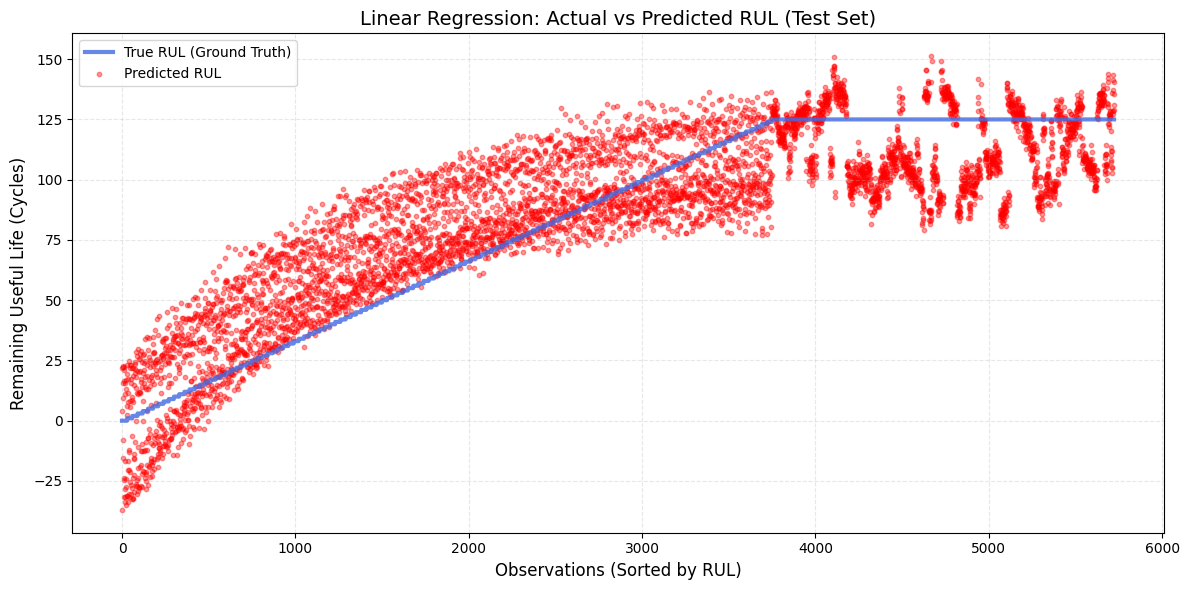

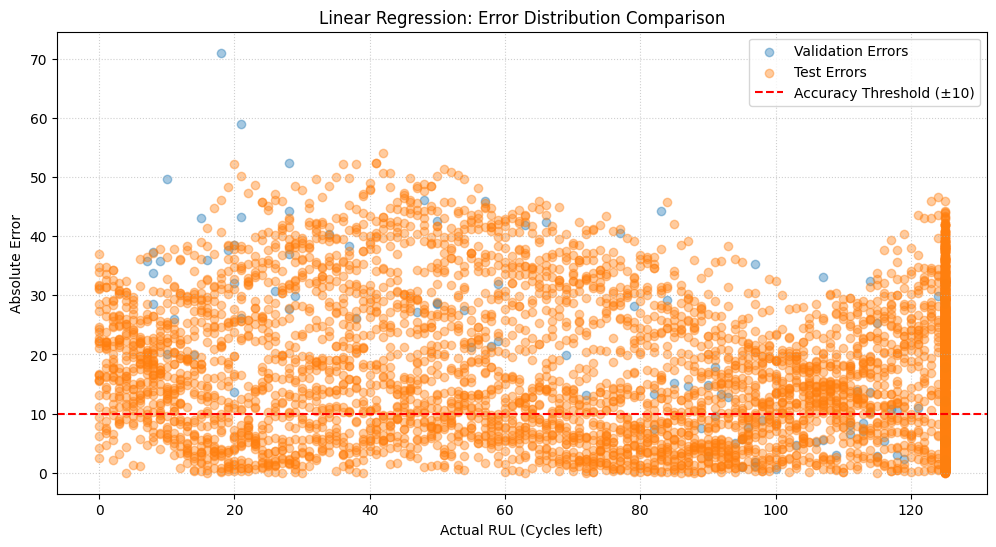


FINAL EVALUATION: Decision Tree

========================= Decision Tree Model Performance =========================
Metric             | Train        | Valid        | Test        
--------------------------------------------------------------------
RMSE               | 4.0775       | 5.2724       | 4.2836      
MAE                | 11.4458      | 21.8268      | 12.6367     
R2 Score           | 0.8399       | 0.5188       | 0.8076      
NASA Score         | 187516.8788  | 13831.8906   | 96666.2073  
Accuracy (±10)     | 54.6619      | 24.0000      | 52.2453     


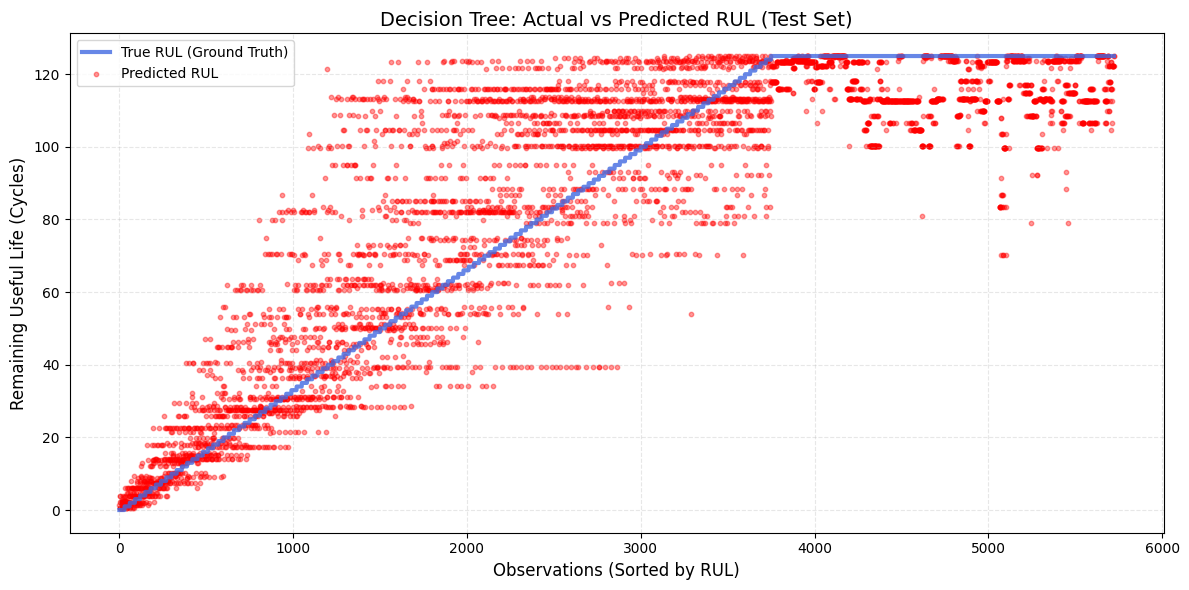

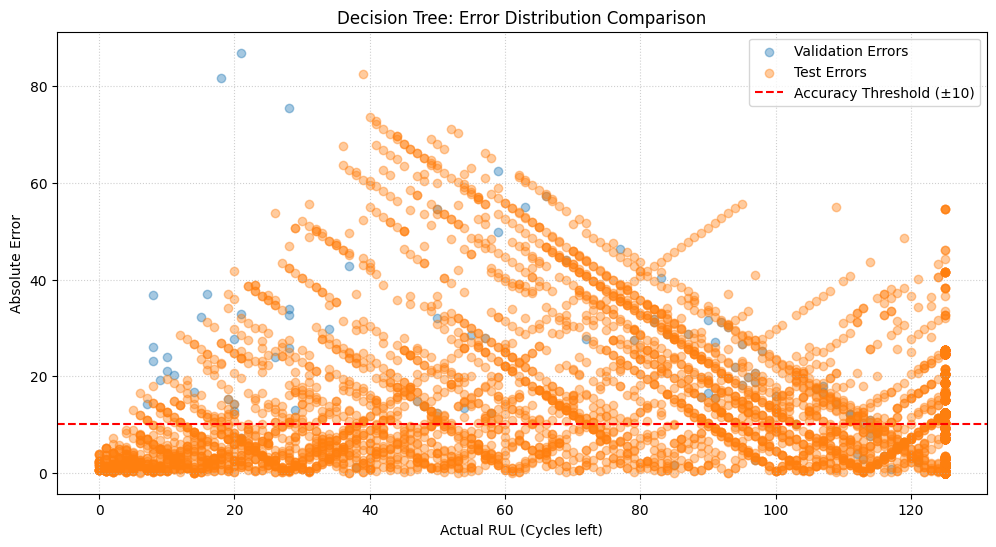


FINAL EVALUATION: Random Forest

========================= Random Forest Model Performance =========================
Metric             | Train        | Valid        | Test        
--------------------------------------------------------------------
RMSE               | 3.5917       | 5.7520       | 4.1978      
MAE                | 9.1273       | 26.7395      | 12.4392     
R2 Score           | 0.9036       | 0.3183       | 0.8225      
NASA Score         | 61072.0540   | 20899.9592   | 76918.1261  
Accuracy (±10)     | 64.2876      | 21.0000      | 53.4160     

⚠️  WARNING: Model lacks CONSISTENCY between Validation and Test sets.


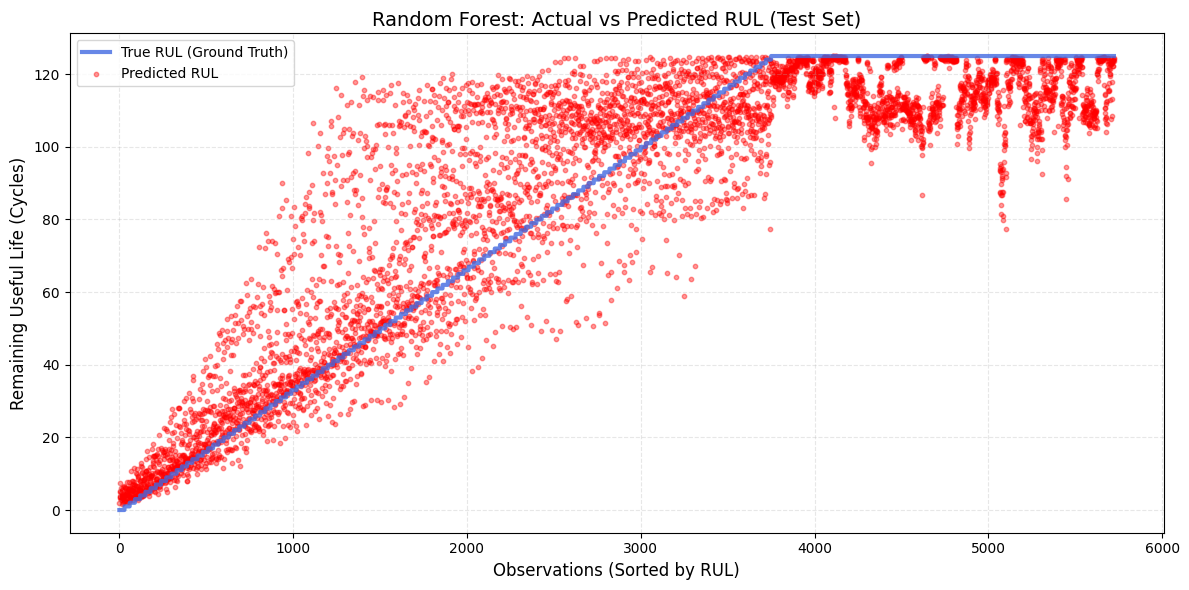

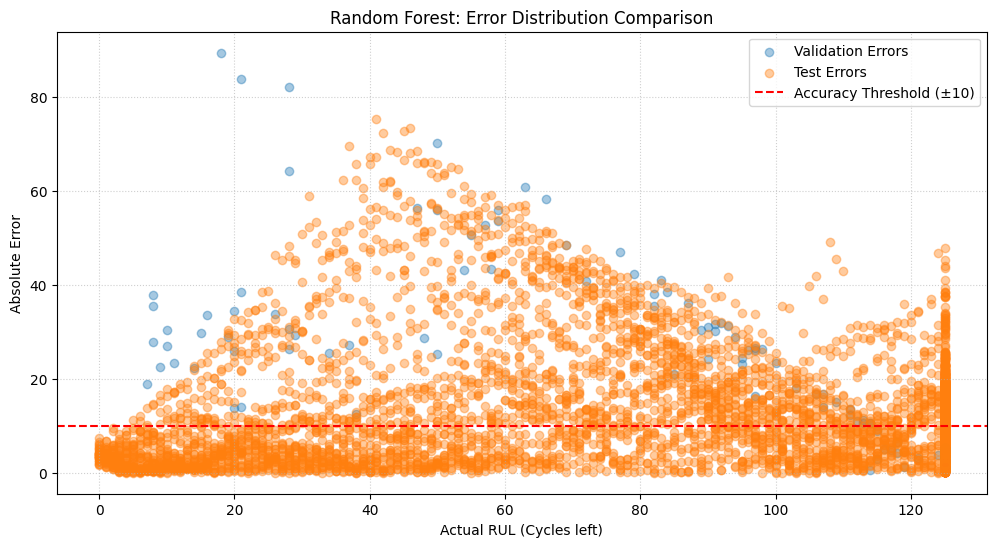


FINAL EVALUATION: XGBoost

========================= XGBoost Model Performance =========================
Metric             | Train        | Valid        | Test        
--------------------------------------------------------------------
RMSE               | 4.0027       | 5.3230       | 4.2296      
MAE                | 11.5847      | 22.5144      | 12.8491     
R2 Score           | 0.8513       | 0.5001       | 0.8171      
NASA Score         | 129707.6543  | 11182.9665   | 76483.2483  
Accuracy (±10)     | 56.1511      | 27.0000      | 51.9658     

⚠️  WARNING: Model lacks CONSISTENCY between Validation and Test sets.


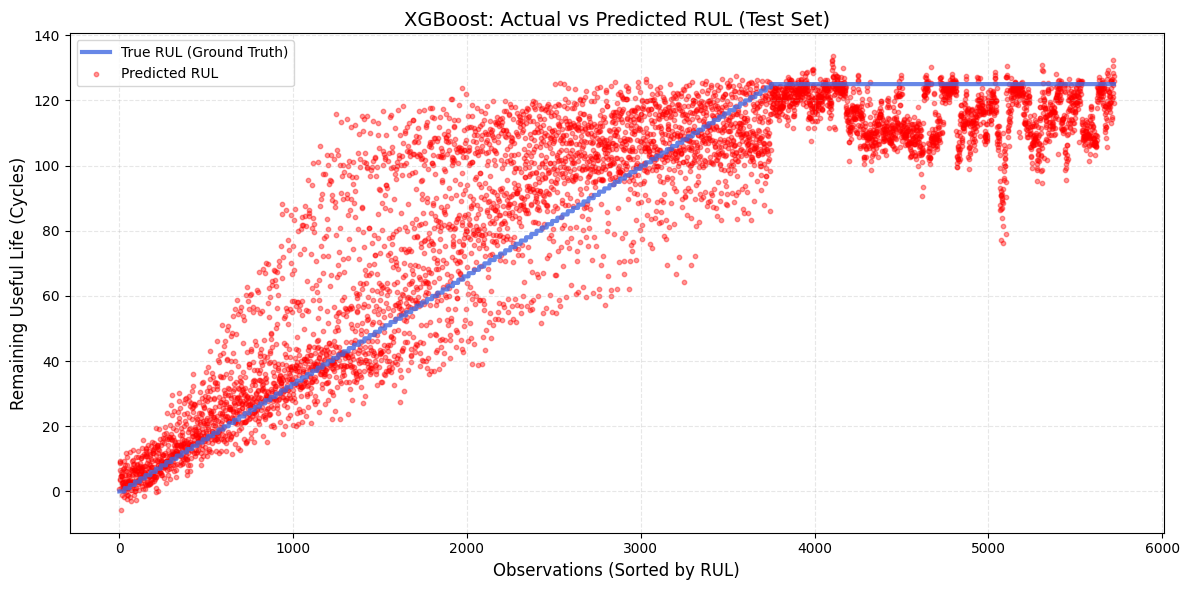

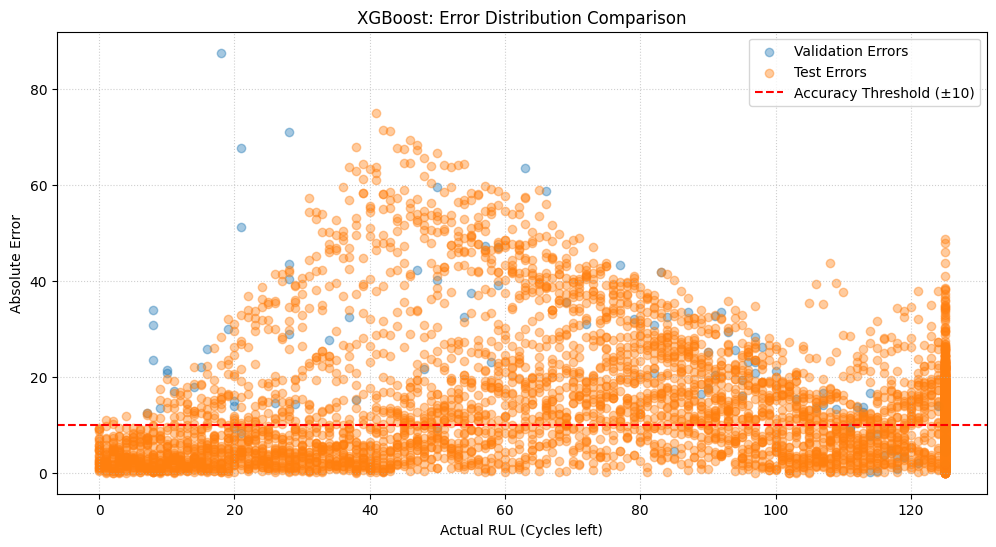


FINAL EVALUATION: SVR

========================= SVR Model Performance =========================
Metric             | Train        | Valid        | Test        
--------------------------------------------------------------------
RMSE               | 4.0683       | 7.2776       | 4.4983      
MAE                | 11.4443      | 42.1545      | 15.9698     
R2 Score           | 0.8413       | -0.7468      | 0.7660      
NASA Score         | 127681.8546  | 156747.6734  | 77396.1207  
Accuracy (±10)     | 56.2517      | 24.0000      | 38.8433     

⚠️  WARNING: High potential for OVERFITTING detected!
   Train RMSE is 44.1% lower than Validation RMSE.

⚠️  WARNING: Model lacks CONSISTENCY between Validation and Test sets.


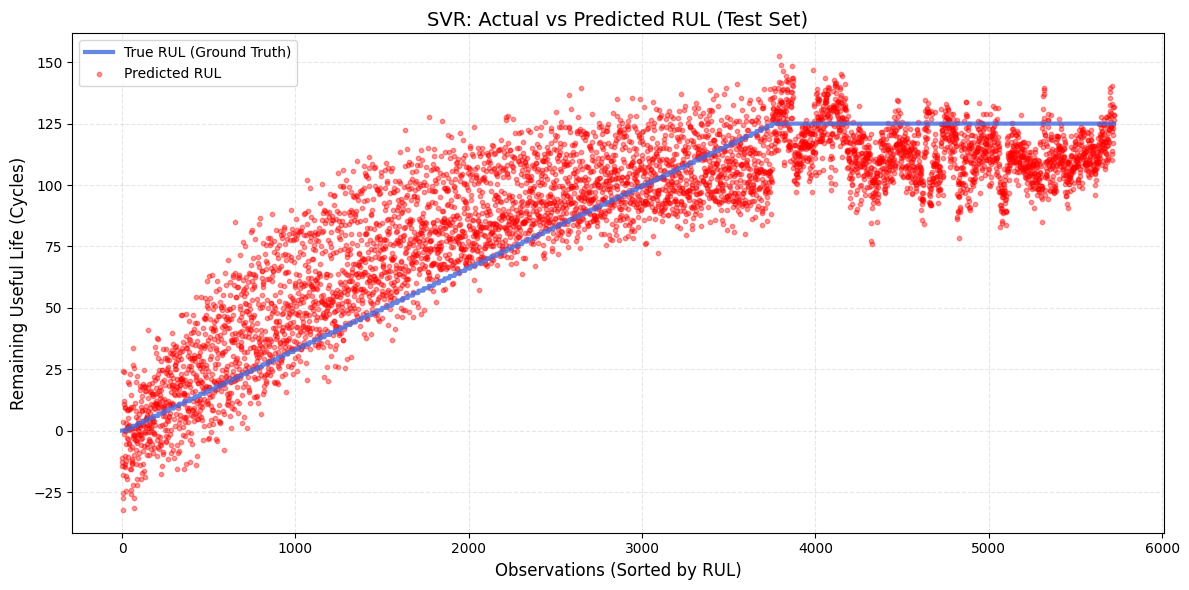

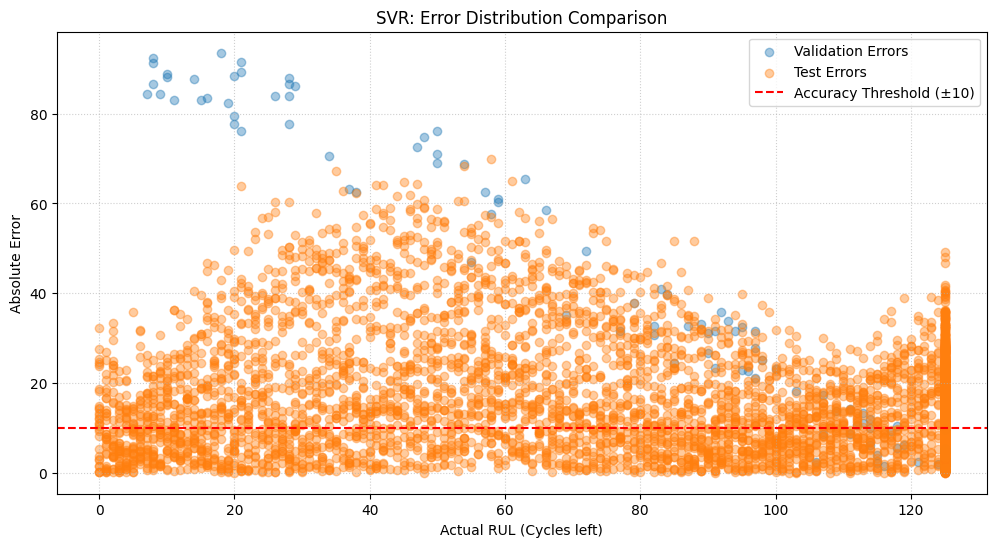


FINAL EVALUATION: Neural Network (ANN)

========================= Neural Network (ANN) Model Performance =========================
Metric             | Train        | Valid        | Test        
--------------------------------------------------------------------
RMSE               | 4.1366       | 7.5933       | 4.1949      
MAE                | 12.5361      | 46.4525      | 12.4792     
R2 Score           | 0.8304       | -1.0702      | 0.8230      
NASA Score         | 158460.4056  | 530603.3905  | 83793.2854  
Accuracy (±10)     | 53.5618      | 19.0000      | 55.5478     

⚠️  WARNING: High potential for OVERFITTING detected!
   Train RMSE is 45.5% lower than Validation RMSE.

⚠️  WARNING: Model lacks CONSISTENCY between Validation and Test sets.


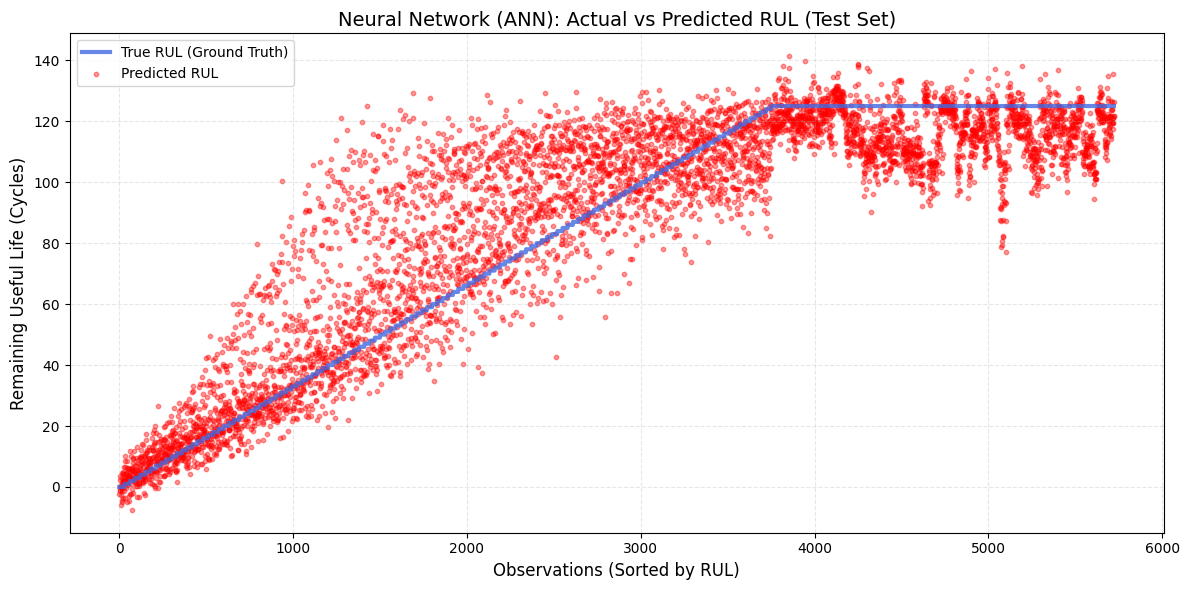

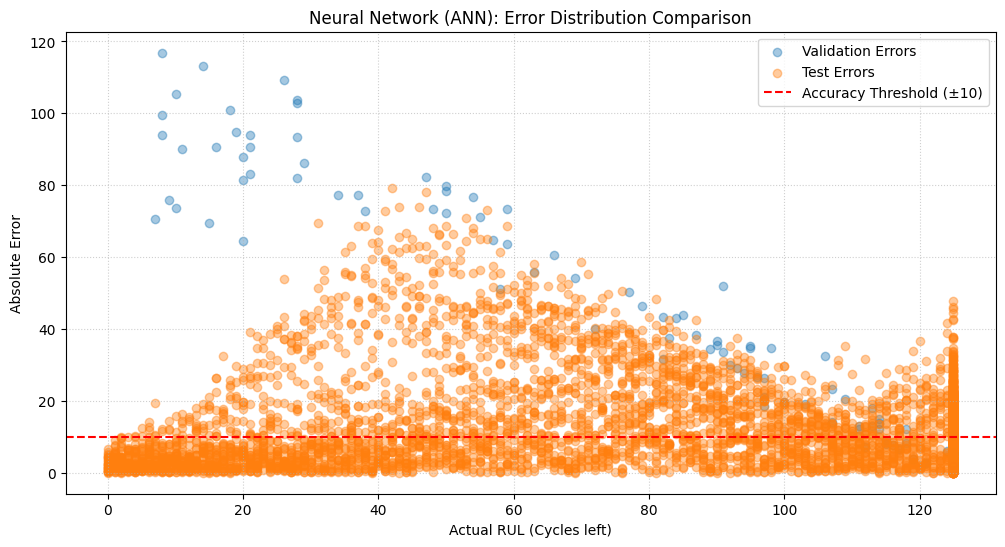

In [26]:
for name, model in models.items():
    print(f"\n" + "="*60)
    print(f"FINAL EVALUATION: {name}")
    print("="*60)
    
    # 1. Generate predictions for all three splits
    # (Using the full datasets as defined in the first step)
    train_preds = model.predict(X_train)
    valid_preds = model.predict(X_valid)
    test_preds  = model.predict(X_test)
    
    # 2. Comprehensive Regression Report
    # Now includes Validation stats to detect overfitting early
    regression_report(
        y_train, train_preds, 
        y_valid, valid_preds, 
        y_test, test_preds, 
        title=f"{name} Model Performance"
    )
    
    # 3. Visualization: Actual vs Predicted (Test Set)
    # Using the 'Sorted' logic to handle the large number of test rows
    plot_comparison(
        y_test, test_preds, 
        title=f"{name}: Actual vs Predicted RUL (Test Set)"
    )
    
    # 4. Safety Check: Error Alignment
    # Passing both Valid and Test to see if the error patterns are consistent
    check_alignment([
        (y_valid, valid_preds, "Validation"),
        (y_test, test_preds, "Test")
    ], title=f"{name}: Error Distribution Comparison")

### Model Comparison

,Train_RMSE,Train_MAE,Train_R2,Valid_RMSE,Valid_MAE,Valid_R2,Test_RMSE,Test_MAE,Test_R2
Model,,,,,,,,,
Neural Network (ANN),4.136615,12.536145,0.830399,7.593319,46.452523,-1.070222,4.194868,12.479204,0.823028
Random Forest,3.591708,9.127296,0.903606,5.752039,26.739497,0.318325,4.197775,12.439153,0.822537
XGBoost,4.002693,11.584671,0.851318,5.322979,22.514377,0.500070,4.229643,12.849108,0.817087
Decision Tree,4.077490,11.445819,0.839890,5.272356,21.826760,0.518818,4.283592,12.636679,0.807574
SVR,4.068279,11.444279,0.841331,7.277612,42.154510,-0.746811,4.498265,15.969821,0.766003
Linear Regression,4.602966,17.344700,0.739985,5.188559,22.003203,0.548688,4.549597,16.996814,0.755137


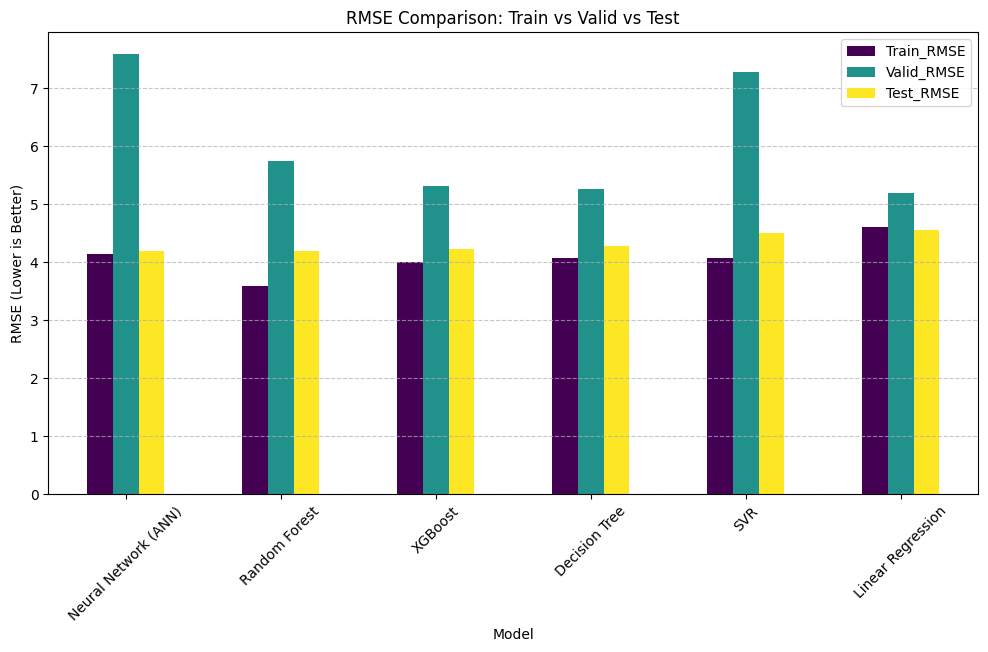

In [27]:
full_report = get_full_performance_report(trained_models, train_df, valid_df, test_df, feature_cols, target_col)
display(full_report)
plot_split_comparison(full_report)

### Model Performance Comparison (Cross-Validation) ###


,CV_RMSE,CV_MAE,CV_R2
Random Forest,17.150639,12.274773,0.829456
XGBoost,17.571463,12.742141,0.820971
Decision Tree,17.789705,12.350665,0.816553
Neural Network (ANN),18.559140,13.781528,0.800357
SVR,20.695685,16.338250,0.751770
Linear Regression,21.233188,17.381290,0.738713


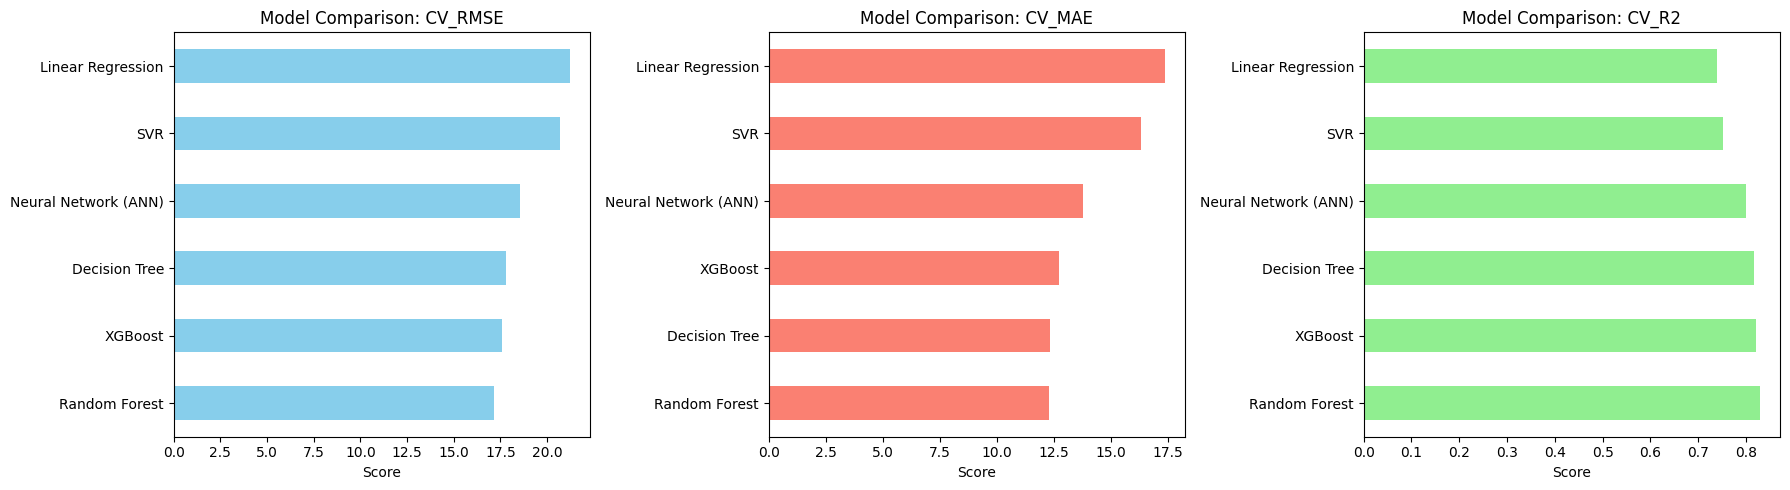

In [28]:
df_comparison = display_model_comparison(results_cv)
plot_model_comparison(df_comparison)